# RhythmMotionCV Notebook 成品版

> 本 Notebook 作为项目提交入口，核心源码、数据结构、评分逻辑与简化版 PyQt 界面都直接写在 Notebook 中。

> Notebook 只继续读取外部资源文件：`跟练视频.MP4`、`data/generated/standard_pose_templates.json`、`data/generated/score_frames.json`、`data/generated/audio.wav`。

> 页面流程保留为：`准备页 -> 实时跟练页 -> 结果页`，并保留关键帧离线验证，便于展示算法效果与交互闭环。

## 建议演示顺序

1. 在项目根目录启动本地 Jupyter。
2. 先运行基础初始化代码单元，加载 Notebook 内置的数据结构、评分算法、关卡数据与资源路径。
3. 再运行关键帧表格单元，展示当前关键帧配置。
4. 运行界面与函数定义单元，加载离线验证函数与 Notebook 内置 PyQt 界面。
5. 先执行离线验证单元，展示标准模板在关键帧上的匹配结果。
6. 最后运行启动单元，打开准备页并进入完整的实时演示流程。

说明：
- 本 Notebook 不复用任何外部 `.py` 源码。
- 实时演示会继续读取外部视频、JSON 数据与音频文件 `data/generated/audio.wav`。
- 启动单元会弹出桌面窗口；关闭窗口后，Notebook 仍可继续使用。

In [ ]:
from __future__ import annotations

from collections import deque
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple
import json
import time

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR = Path.cwd()
if not (BASE_DIR / "data" / "generated").exists():
    raise RuntimeError("请在项目根目录启动 Jupyter，再运行本 Notebook。")


@dataclass(frozen=True)
class NotebookPaths:
    video_path: Path = BASE_DIR / "跟练视频.MP4"
    standard_template_path: Path = BASE_DIR / "data" / "generated" / "standard_pose_templates.json"
    score_frame_path: Path = BASE_DIR / "data" / "generated" / "score_frames.json"
    thumbnail_path: Path = BASE_DIR / "data" / "generated" / "thumbnail.jpg"
    audio_path: Path = BASE_DIR / "data" / "generated" / "audio.wav"


@dataclass(frozen=True)
class ScoreConfig:
    pass_threshold: int = 80
    warn_threshold: int = 60
    min_core_visibility: float = 0.60
    max_sample_delay_ms: int = 100
    score_trigger_lookahead_ms: int = 40
    combo_trigger_count: int = 2
    combo_bonus_step: float = 0.20
    combo_bonus_cap: float = 2.00


@dataclass(frozen=True)
class RuntimeConfig:
    camera_id: int = 0
    camera_width: int = 960
    camera_height: int = 720
    camera_retry_limit: int = 60
    pose_model_complexity: int = 1
    detection_confidence: float = 0.55
    tracking_confidence: float = 0.55
    pose_smoothing_alpha: float = 0.65


PATHS = NotebookPaths()
SCORE_RULES = ScoreConfig()
RUNTIME = RuntimeConfig()
NOTEBOOK_COLORS = {
    "primary": "#0F62FE",
    "primary_dark": "#0B3EA8",
    "success": "#1FA971",
    "warning": "#E0A100",
    "error": "#E5484D",
    "background": "#F5F7FB",
    "panel": "#FFFFFF",
    "panel_alt": "#EEF4FF",
    "text": "#162033",
    "muted": "#667085",
    "border": "#D8E0EE",
    "accent": "#E9F1FF",
}
LEVEL_INFO_FALLBACK = {
    "action_name": "单关卡健康跟练",
    "subtitle": "跟随示范动作完成一次稳定、轻量、闭环的姿态训练",
    "difficulty": "初级",
    "coach_name": "标准示范视频",
    "notes": [
        "保持全身尽量完整出现在镜头中",
        "动作以标准和稳定为主，不必追求速度",
        "到达关键得分帧时尽量保持动作到位",
    ],
}
ACTION_HINT_LIBRARY = {
    "raise_arms": "手臂再抬高一点，让手腕高于肩线",
    "open_chest": "肩部再打开一点，保持躯干挺直",
    "squat": "再下蹲一些，注意膝盖朝向脚尖",
    "lunge": "弓步幅度可以再明确，保持重心稳定",
    "twist": "上半身扭转幅度再大一点，核心保持收紧",
    "throw": "手臂甩出去的幅度再大一点",
    "pull_down": "从上往下拉的动作再用力一些",
    "wrist_rotate": "手腕旋转的幅度再大一些",
    "knock": "敲击动作再有力一些",
    "clap": "鼓掌再响亮一些，双手拍合到位",
    "wave": "挥手幅度再大一些",
    "step": "踏步动作再有力，抬腿再高一点",
    "body_shake": "全身摇摆幅度再大一些",
    "jump": "跳得再高一些，双脚离地",
    "default": "动作幅度再靠近示范姿态，保持稳定呼吸",
}

_MP_POSE = mp.solutions.pose
CORE_JOINTS: List[Tuple[str, int]] = [
    ("left_shoulder", _MP_POSE.PoseLandmark.LEFT_SHOULDER.value),
    ("right_shoulder", _MP_POSE.PoseLandmark.RIGHT_SHOULDER.value),
    ("left_elbow", _MP_POSE.PoseLandmark.LEFT_ELBOW.value),
    ("right_elbow", _MP_POSE.PoseLandmark.RIGHT_ELBOW.value),
    ("left_wrist", _MP_POSE.PoseLandmark.LEFT_WRIST.value),
    ("right_wrist", _MP_POSE.PoseLandmark.RIGHT_WRIST.value),
    ("left_hip", _MP_POSE.PoseLandmark.LEFT_HIP.value),
    ("right_hip", _MP_POSE.PoseLandmark.RIGHT_HIP.value),
    ("left_knee", _MP_POSE.PoseLandmark.LEFT_KNEE.value),
    ("right_knee", _MP_POSE.PoseLandmark.RIGHT_KNEE.value),
    ("left_ankle", _MP_POSE.PoseLandmark.LEFT_ANKLE.value),
    ("right_ankle", _MP_POSE.PoseLandmark.RIGHT_ANKLE.value),
]
_MIRROR_INDEX_MAP = np.array([1, 0, 3, 2, 5, 4, 7, 6, 9, 8, 11, 10], dtype=np.int32)
DRAW_CONNECTIONS: List[Tuple[int, int]] = [
    (_MP_POSE.PoseLandmark.LEFT_SHOULDER.value, _MP_POSE.PoseLandmark.RIGHT_SHOULDER.value),
    (_MP_POSE.PoseLandmark.LEFT_SHOULDER.value, _MP_POSE.PoseLandmark.LEFT_ELBOW.value),
    (_MP_POSE.PoseLandmark.LEFT_ELBOW.value, _MP_POSE.PoseLandmark.LEFT_WRIST.value),
    (_MP_POSE.PoseLandmark.RIGHT_SHOULDER.value, _MP_POSE.PoseLandmark.RIGHT_ELBOW.value),
    (_MP_POSE.PoseLandmark.RIGHT_ELBOW.value, _MP_POSE.PoseLandmark.RIGHT_WRIST.value),
    (_MP_POSE.PoseLandmark.LEFT_SHOULDER.value, _MP_POSE.PoseLandmark.LEFT_HIP.value),
    (_MP_POSE.PoseLandmark.RIGHT_SHOULDER.value, _MP_POSE.PoseLandmark.RIGHT_HIP.value),
    (_MP_POSE.PoseLandmark.LEFT_HIP.value, _MP_POSE.PoseLandmark.RIGHT_HIP.value),
    (_MP_POSE.PoseLandmark.LEFT_HIP.value, _MP_POSE.PoseLandmark.LEFT_KNEE.value),
    (_MP_POSE.PoseLandmark.LEFT_KNEE.value, _MP_POSE.PoseLandmark.LEFT_ANKLE.value),
    (_MP_POSE.PoseLandmark.RIGHT_HIP.value, _MP_POSE.PoseLandmark.RIGHT_KNEE.value),
    (_MP_POSE.PoseLandmark.RIGHT_KNEE.value, _MP_POSE.PoseLandmark.RIGHT_ANKLE.value),
]
PRIMARY_BGR = (254, 98, 15)
SUCCESS_BGR = (113, 169, 31)
WARNING_BGR = (0, 161, 224)
ERROR_BGR = (77, 72, 229)


@dataclass
class PoseDetectionResult:
    visible: bool
    landmarks: List[Dict[str, float]] = field(default_factory=list)
    normalized_vector: Optional[np.ndarray] = None
    core_visibility: float = 0.0
    missing_core_joints: List[str] = field(default_factory=list)


@dataclass
class KeyframeRecord:
    template_id: str
    timestamp_ms: int
    frame_index: int
    label: str
    action: str
    correction_hint: str
    pass_threshold: int
    warn_threshold: int
    template_vector: np.ndarray


@dataclass
class LevelBundle:
    video_path: Path
    thumbnail_path: Path
    audio_path: Optional[Path]
    video_duration_ms: int
    action_name: str
    subtitle: str
    difficulty: str
    coach_name: str
    notes: List[str]
    keyframes: List[KeyframeRecord]


class PoseDetector:
    def __init__(
        self,
        static_image_mode: bool = False,
        model_complexity: int = 1,
        min_detection_confidence: float = 0.55,
        min_tracking_confidence: float = 0.55,
    ) -> None:
        self._pose = _MP_POSE.Pose(
            static_image_mode=static_image_mode,
            model_complexity=model_complexity,
            enable_segmentation=False,
            min_detection_confidence=min_detection_confidence,
            min_tracking_confidence=min_tracking_confidence,
        )

    def detect(self, frame_bgr: np.ndarray) -> PoseDetectionResult:
        rgb_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        result = self._pose.process(rgb_frame)
        if not result.pose_landmarks:
            return PoseDetectionResult(visible=False)

        landmarks: List[Dict[str, float]] = []
        for landmark in result.pose_landmarks.landmark:
            landmarks.append(
                {
                    "x": float(landmark.x),
                    "y": float(landmark.y),
                    "z": float(landmark.z),
                    "visibility": float(getattr(landmark, "visibility", 1.0)),
                }
            )

        vector, core_visibility, missing = normalize_core_joints(landmarks)
        return PoseDetectionResult(
            visible=True,
            landmarks=landmarks,
            normalized_vector=vector,
            core_visibility=core_visibility,
            missing_core_joints=missing,
        )

    def close(self) -> None:
        self._pose.close()


class PoseSmoother:
    def __init__(self, alpha: float = 0.65) -> None:
        self.alpha = alpha
        self._state: Optional[np.ndarray] = None

    def update(self, vector: Optional[np.ndarray]) -> Optional[np.ndarray]:
        if vector is None:
            self._state = None
            return None
        if self._state is None:
            self._state = vector.astype(np.float32)
            return self._state.copy()
        self._state = self.alpha * self._state + (1.0 - self.alpha) * vector.astype(np.float32)
        return self._state.copy()

    def reset(self) -> None:
        self._state = None


def resolve_resource_path(raw_path: str | Path | None, default_path: Path) -> Path:
    candidate = Path(raw_path) if raw_path else default_path
    if not candidate.is_absolute():
        candidate = BASE_DIR / candidate
    return candidate.resolve()


def load_json(json_path: Path) -> Dict[str, Any]:
    with json_path.open("r", encoding="utf-8") as file:
        return json.load(file)


def normalize_core_joints(
    landmarks: Sequence[Dict[str, float]],
    visibility_threshold: float = 0.45,
) -> Tuple[Optional[np.ndarray], float, List[str]]:
    if len(landmarks) <= max(index for _, index in CORE_JOINTS):
        return None, 0.0, [name for name, _ in CORE_JOINTS]

    left_shoulder = landmarks[_MP_POSE.PoseLandmark.LEFT_SHOULDER.value]
    right_shoulder = landmarks[_MP_POSE.PoseLandmark.RIGHT_SHOULDER.value]
    left_hip = landmarks[_MP_POSE.PoseLandmark.LEFT_HIP.value]
    right_hip = landmarks[_MP_POSE.PoseLandmark.RIGHT_HIP.value]

    shoulder_mid = np.array(
        [
            (left_shoulder["x"] + right_shoulder["x"]) * 0.5,
            (left_shoulder["y"] + right_shoulder["y"]) * 0.5,
        ],
        dtype=np.float32,
    )
    hip_mid = np.array(
        [
            (left_hip["x"] + right_hip["x"]) * 0.5,
            (left_hip["y"] + right_hip["y"]) * 0.5,
        ],
        dtype=np.float32,
    )
    trunk_length = float(np.linalg.norm(hip_mid - shoulder_mid))
    if trunk_length < 1e-6:
        return None, 0.0, [name for name, _ in CORE_JOINTS]

    normalized_points: List[float] = []
    missing: List[str] = []
    visibility_scores: List[float] = []
    for joint_name, joint_index in CORE_JOINTS:
        landmark = landmarks[joint_index]
        visibility = float(landmark.get("visibility", 1.0))
        visibility_scores.append(visibility)
        if visibility < visibility_threshold:
            missing.append(joint_name)
        normalized_points.append((float(landmark["x"]) - float(shoulder_mid[0])) / trunk_length)
        normalized_points.append((float(landmark["y"]) - float(shoulder_mid[1])) / trunk_length)

    return np.array(normalized_points, dtype=np.float32), float(np.mean(visibility_scores)), missing


def mirror_normalized_vector(vector: np.ndarray) -> np.ndarray:
    matrix = np.asarray(vector, dtype=np.float32).reshape(len(CORE_JOINTS), 2)
    mirrored = matrix[_MIRROR_INDEX_MAP].copy()
    mirrored[:, 0] *= -1.0
    return mirrored.reshape(-1)


def _vector_cosine_to_score(first: np.ndarray, second: np.ndarray) -> float:
    first_norm = float(np.linalg.norm(first))
    second_norm = float(np.linalg.norm(second))
    if first_norm < 1e-8 or second_norm < 1e-8:
        return 0.0
    cosine_value = float(np.dot(first, second) / (first_norm * second_norm))
    cosine_value = max(-1.0, min(1.0, cosine_value))
    return max(0.0, min(100.0, cosine_value * 100.0))


def cosine_similarity_score(user_vector: np.ndarray, template_vector: np.ndarray) -> Tuple[float, bool]:
    direct_score = _vector_cosine_to_score(user_vector, template_vector)
    mirrored_score = _vector_cosine_to_score(mirror_normalized_vector(user_vector), template_vector)
    if mirrored_score > direct_score:
        return mirrored_score, True
    return direct_score, False


def classify_score(score_value: float, pass_threshold: int, warn_threshold: int) -> str:
    if score_value >= pass_threshold:
        return "pass"
    if score_value >= warn_threshold:
        return "warn"
    return "fail"


def combo_multiplier(combo_count: int) -> float:
    if combo_count < SCORE_RULES.combo_trigger_count:
        return 1.0
    bonus_steps = combo_count - SCORE_RULES.combo_trigger_count + 1
    return min(1.0 + bonus_steps * SCORE_RULES.combo_bonus_step, SCORE_RULES.combo_bonus_cap)


def infer_correction_hint(
    user_vector: Optional[np.ndarray],
    template_vector: np.ndarray,
    action_name: str,
    fallback_hint: str = "",
) -> str:
    if user_vector is None:
        return "请保持全身入镜后重新完成动作"

    hint_text = fallback_hint.strip() if fallback_hint else ACTION_HINT_LIBRARY.get(action_name, ACTION_HINT_LIBRARY["default"])
    user_matrix = np.asarray(user_vector, dtype=np.float32).reshape(len(CORE_JOINTS), 2)
    template_matrix = np.asarray(template_vector, dtype=np.float32).reshape(len(CORE_JOINTS), 2)
    joint_errors = np.linalg.norm(template_matrix - user_matrix, axis=1)
    joint_name = CORE_JOINTS[int(np.argmax(joint_errors))][0]

    if "wrist" in joint_name or "elbow" in joint_name:
        return "手臂角度还可以再展开一些，尽量贴近示范动作"
    if "knee" in joint_name or "ankle" in joint_name:
        return "下肢动作再稳定一些，注意膝踝保持方向一致"
    if "hip" in joint_name:
        return "核心保持收紧，臀髋位置再接近示范姿态"
    if "shoulder" in joint_name:
        return "肩部姿态再打开一些，保持上半身挺拔"
    return hint_text


def draw_pose_overlay(frame_bgr: np.ndarray, landmarks: Sequence[Dict[str, float]]) -> np.ndarray:
    canvas = frame_bgr.copy()
    height, width = canvas.shape[:2]
    for start_index, end_index in DRAW_CONNECTIONS:
        start_lm = landmarks[start_index]
        end_lm = landmarks[end_index]
        if min(start_lm.get("visibility", 0.0), end_lm.get("visibility", 0.0)) < 0.35:
            continue
        start_point = (int(start_lm["x"] * width), int(start_lm["y"] * height))
        end_point = (int(end_lm["x"] * width), int(end_lm["y"] * height))
        cv2.line(canvas, start_point, end_point, PRIMARY_BGR, 4, cv2.LINE_AA)

    for _, joint_index in CORE_JOINTS:
        joint = landmarks[joint_index]
        if joint.get("visibility", 0.0) < 0.35:
            continue
        point = (int(joint["x"] * width), int(joint["y"] * height))
        cv2.circle(canvas, point, 7, (255, 255, 255), -1, cv2.LINE_AA)
        cv2.circle(canvas, point, 10, PRIMARY_BGR, 2, cv2.LINE_AA)
    return canvas


def read_video_metadata(video_path: Path) -> Dict[str, Any]:
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        return {
            "opened": False,
            "fps": 0.0,
            "frame_count": 0,
            "duration_ms": 0,
            "width": 0,
            "height": 0,
        }
    fps_value = float(capture.get(cv2.CAP_PROP_FPS) or 0.0)
    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    capture.release()
    duration_ms = int((frame_count / fps_value) * 1000) if fps_value > 0 else 0
    return {
        "opened": True,
        "fps": fps_value,
        "frame_count": frame_count,
        "duration_ms": duration_ms,
        "width": width,
        "height": height,
    }


def load_level_bundle(
    template_path: Path = PATHS.standard_template_path,
    score_frame_path: Path = PATHS.score_frame_path,
) -> LevelBundle:
    template_payload = load_json(template_path)
    score_payload = load_json(score_frame_path)

    template_map: Dict[str, Dict[str, Any]] = {}
    for item in template_payload.get("templates", []):
        template_id = str(item.get("template_id", "")).strip()
        if template_id:
            template_map[template_id] = item

    keyframes: List[KeyframeRecord] = []
    for item in score_payload.get("keyframes", []):
        template_id = str(item.get("template_id", "")).strip()
        template_data = template_map.get(template_id)
        if not template_data:
            continue

        template_vector = np.array(template_data.get("template_vector", []), dtype=np.float32)
        if template_vector.size != len(CORE_JOINTS) * 2:
            continue

        keyframes.append(
            KeyframeRecord(
                template_id=template_id,
                timestamp_ms=int(item.get("timestamp_ms", 0)),
                frame_index=int(item.get("frame_index", template_data.get("frame_index", 0))),
                label=str(item.get("label", "关键帧")),
                action=str(item.get("action", "default")),
                correction_hint=str(item.get("correction_hint", "")),
                pass_threshold=int(item.get("pass_threshold", SCORE_RULES.pass_threshold)),
                warn_threshold=int(item.get("warn_threshold", SCORE_RULES.warn_threshold)),
                template_vector=template_vector,
            )
        )

    if not keyframes:
        raise RuntimeError("未在关键帧配置中找到可用模板，请确认 JSON 数据已经生成。")

    keyframes.sort(key=lambda item: item.timestamp_ms)
    audio_path = PATHS.audio_path.resolve() if PATHS.audio_path.exists() else None
    return LevelBundle(
        video_path=resolve_resource_path(score_payload.get("video_path"), PATHS.video_path),
        thumbnail_path=resolve_resource_path(score_payload.get("thumbnail_path"), PATHS.thumbnail_path),
        audio_path=audio_path,
        video_duration_ms=int(score_payload.get("video_duration_ms", 0)),
        action_name=str(score_payload.get("action_name", LEVEL_INFO_FALLBACK["action_name"])),
        subtitle=str(score_payload.get("subtitle", LEVEL_INFO_FALLBACK["subtitle"])),
        difficulty=str(score_payload.get("difficulty", LEVEL_INFO_FALLBACK["difficulty"])),
        coach_name=str(score_payload.get("coach_name", LEVEL_INFO_FALLBACK["coach_name"])),
        notes=list(score_payload.get("notes", LEVEL_INFO_FALLBACK["notes"])),
        keyframes=keyframes,
    )


def ms_to_timestamp(ms_value: int) -> str:
    total_seconds = max(0, int(round(ms_value / 1000.0)))
    minutes, seconds = divmod(total_seconds, 60)
    return f"{minutes:02d}:{seconds:02d}"


bundle = load_level_bundle()
video_meta = read_video_metadata(bundle.video_path)
if bundle.video_duration_ms <= 0:
    bundle.video_duration_ms = int(video_meta.get("duration_ms", 0))

audio_status = str(bundle.audio_path) if bundle.audio_path is not None else "未找到 data/generated/audio.wav"
print(f"视频路径: {bundle.video_path}")
print(f"关键帧数量: {len(bundle.keyframes)}")
print(f"视频时长: {video_meta['duration_ms'] / 1000:.2f}s")
print(f"示范标题: {bundle.action_name}")
print(f"音频资源: {audio_status}")

视频路径: E:\OneDrive\CV\cv_Project\CV_PROJECT\RhythmMotionCV\跟练视频.MP4
关键帧数量: 8
视频时长: 148.13s
示范标题: 单关卡健康跟练
音频资源: E:\OneDrive\CV\cv_Project\CV_PROJECT\RhythmMotionCV\data\generated\audio.wav


In [23]:
keyframe_df = pd.DataFrame(
    [
        {
            "序号": index,
            "template_id": keyframe.template_id,
            "frame_index": keyframe.frame_index,
            "timestamp_ms": keyframe.timestamp_ms,
            "时间": ms_to_timestamp(keyframe.timestamp_ms),
            "动作": keyframe.action,
            "标签": keyframe.label,
            "pass_threshold": keyframe.pass_threshold,
            "warn_threshold": keyframe.warn_threshold,
        }
        for index, keyframe in enumerate(bundle.keyframes, start=1)
    ]
)

keyframe_df

,序号,template_id,frame_index,timestamp_ms,时间,动作,标签,pass_threshold,warn_threshold
0,1,kf_001,1215,40500,00:40,wrist_rotate,手腕旋转,80,60
1,2,kf_002,1665,55500,00:56,knock,敲击动作,80,60
2,3,kf_003,2019,67300,01:07,clap,鼓掌,80,60
3,4,kf_004,2715,90500,01:30,wave,挥舞动作,80,60
4,5,kf_005,2829,94300,01:34,step,踏步动作,80,60
5,6,kf_006,3381,112700,01:53,body_shake,全身摇动,80,60
6,7,kf_007,3780,126000,02:06,wrist_rotate,手腕旋转,80,60
7,8,kf_008,4230,141000,02:21,jump,跳动,80,60


In [24]:
try:
    from IPython import get_ipython
except ImportError:
    def get_ipython():
        return None

In [32]:
from PyQt5.QtCore import QRectF, Qt, QTimer, QUrl
from PyQt5.QtGui import QColor, QFont, QImage, QPainter, QPen, QPixmap
try:
    from PyQt5.QtMultimedia import QSoundEffect
except ImportError:
    QSoundEffect = None
from PyQt5.QtWidgets import (
    QApplication,
    QFrame,
    QGridLayout,
    QHBoxLayout,
    QLabel,
    QMainWindow,
    QPushButton,
    QStackedWidget,
    QVBoxLayout,
    QWidget,
)


def evaluate_demo_keyframes(level_bundle=None):
    level_bundle = level_bundle or bundle
    detector = PoseDetector(static_image_mode=True)
    capture = cv2.VideoCapture(str(level_bundle.video_path))
    rows = []

    try:
        if not capture.isOpened():
            raise RuntimeError(f"无法打开示范视频: {level_bundle.video_path}")

        for index, keyframe in enumerate(level_bundle.keyframes, start=1):
            capture.set(cv2.CAP_PROP_POS_FRAMES, keyframe.frame_index)
            success, frame = capture.read()
            if not success or frame is None:
                rows.append(
                    {
                        "序号": index,
                        "标签": keyframe.label,
                        "时间": ms_to_timestamp(keyframe.timestamp_ms),
                        "score": 0.0,
                        "grade": "fail",
                        "备注": "视频帧读取失败",
                    }
                )
                continue

            detection = detector.detect(frame)
            if not detection.visible or detection.normalized_vector is None:
                rows.append(
                    {
                        "序号": index,
                        "标签": keyframe.label,
                        "时间": ms_to_timestamp(keyframe.timestamp_ms),
                        "score": 0.0,
                        "grade": "fail",
                        "备注": "该关键帧未检测到人体",
                    }
                )
                continue

            score, mirrored = cosine_similarity_score(detection.normalized_vector, keyframe.template_vector)
            grade = classify_score(score, keyframe.pass_threshold, keyframe.warn_threshold)
            rows.append(
                {
                    "序号": index,
                    "标签": keyframe.label,
                    "时间": ms_to_timestamp(keyframe.timestamp_ms),
                    "score": round(score, 2),
                    "grade": grade,
                    "备注": "镜像比对" if mirrored else "直接比对",
                }
            )
    finally:
        capture.release()
        detector.close()

    result_df = pd.DataFrame(rows)
    if not result_df.empty:
        color_map = {"pass": "#1FA971", "warn": "#E0A100", "fail": "#E5484D"}
        plt.figure(figsize=(10, 4.5))
        plt.bar(
            result_df["标签"],
            result_df["score"],
            color=[color_map.get(item, "#94A3B8") for item in result_df["grade"]],
        )
        plt.axhline(SCORE_RULES.pass_threshold, color="#0B7A4B", linestyle="--", linewidth=1.4)
        plt.axhline(SCORE_RULES.warn_threshold, color="#C58A00", linestyle="--", linewidth=1.4)
        plt.ylabel("模板匹配分数")
        plt.title("示范视频固定关键帧离线验证")
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()

    return result_df


def build_rating(final_score: int, pass_rate: float) -> Tuple[str, str]:
    if pass_rate >= 0.9 and final_score > 0:
        return "S 评级", NOTEBOOK_COLORS["success"]
    if pass_rate >= 0.75:
        return "A 评级", NOTEBOOK_COLORS["primary"]
    if pass_rate >= 0.55:
        return "B 评级", NOTEBOOK_COLORS["warning"]
    return "C 评级", NOTEBOOK_COLORS["error"]


def build_font(pixel_size: int, bold: bool = False) -> QFont:
    font = QFont("Microsoft YaHei UI")
    font.setPixelSize(pixel_size)
    font.setBold(bold)
    return font


def frame_to_pixmap(frame_bgr: np.ndarray, target_width: int, target_height: int) -> QPixmap:
    rgb_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    height, width, channel = rgb_frame.shape
    image = QImage(rgb_frame.data, width, height, channel * width, QImage.Format_RGB888).copy()
    pixmap = QPixmap.fromImage(image)
    return pixmap.scaled(target_width, target_height, Qt.KeepAspectRatio, Qt.SmoothTransformation)


def build_panel_style(background: str = None, border: str = None, radius: int = 18) -> str:
    panel_bg = background or NOTEBOOK_COLORS["panel"]
    panel_border = border or NOTEBOOK_COLORS["border"]
    return f"background: {panel_bg}; border: 1px solid {panel_border}; border-radius: {radius}px;"


def build_badge_style(background: str, text_color: str = "white") -> str:
    return f"background: {background}; color: {text_color}; border-radius: 12px; padding: 6px 12px;"


class TimelineWidget(QWidget):
    def __init__(self, parent=None) -> None:
        super().__init__(parent)
        self._duration_ms = 1
        self._current_ms = 0
        self._markers: List[int] = []
        self._completed_count = 0
        self._active_index = -1
        self.setMinimumHeight(42)

    def set_timeline(self, duration_ms: int, markers: Sequence[int]) -> None:
        self._duration_ms = max(1, int(duration_ms))
        self._markers = [int(item) for item in markers]
        self.update()

    def set_state(self, current_ms: int, completed_count: int, active_index: int) -> None:
        self._current_ms = max(0, int(current_ms))
        self._completed_count = max(0, int(completed_count))
        self._active_index = int(active_index)
        self.update()

    def paintEvent(self, event) -> None:
        _ = event
        painter = QPainter(self)
        painter.setRenderHint(QPainter.Antialiasing)

        track_rect = QRectF(18, 18, max(30, self.width() - 36), 8)
        center_y = track_rect.center().y()
        radius = 6

        painter.setPen(Qt.NoPen)
        painter.setBrush(QColor("#E6ECF5"))
        painter.drawRoundedRect(track_rect, 4, 4)

        progress_width = track_rect.width() * min(1.0, float(self._current_ms) / float(self._duration_ms))
        painter.setBrush(QColor(NOTEBOOK_COLORS["primary"]))
        painter.drawRoundedRect(QRectF(track_rect.x(), track_rect.y(), progress_width, track_rect.height()), 4, 4)

        for index, marker_ms in enumerate(self._markers):
            ratio = min(1.0, max(0.0, float(marker_ms) / float(self._duration_ms)))
            x_pos = track_rect.x() + track_rect.width() * ratio
            if index < self._completed_count:
                fill_color = QColor(NOTEBOOK_COLORS["success"])
                pen_color = QColor("#FFFFFF")
                marker_radius = radius + 1
            elif index == self._active_index:
                fill_color = QColor(NOTEBOOK_COLORS["warning"])
                pen_color = QColor(NOTEBOOK_COLORS["primary_dark"])
                marker_radius = radius + 2
            else:
                fill_color = QColor("#FFFFFF")
                pen_color = QColor(NOTEBOOK_COLORS["primary"])
                marker_radius = radius

            painter.setBrush(fill_color)
            painter.setPen(QPen(pen_color, 2))
            painter.drawEllipse(QRectF(x_pos - marker_radius, center_y - marker_radius, marker_radius * 2, marker_radius * 2))


class MetricCard(QFrame):
    def __init__(self, title: str) -> None:
        super().__init__()
        self.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel"], NOTEBOOK_COLORS["border"], radius=16))
        layout = QVBoxLayout(self)
        layout.setContentsMargins(16, 14, 16, 14)
        layout.setSpacing(6)

        self.title_label = QLabel(title)
        self.title_label.setFont(build_font(12, bold=True))
        self.title_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['muted']};")

        self.value_label = QLabel("--")
        self.value_label.setFont(build_font(26, bold=True))
        self.value_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")

        layout.addWidget(self.title_label)
        layout.addWidget(self.value_label)

    def set_value(self, value: str, color: str = None) -> None:
        self.value_label.setText(value)
        self.value_label.setStyleSheet(f"color: {color or NOTEBOOK_COLORS['text']};")


class NotebookPreparePage(QWidget):
    def __init__(self) -> None:
        super().__init__()
        root = QVBoxLayout(self)
        root.setContentsMargins(34, 28, 34, 28)
        root.setSpacing(22)

        hero = QFrame()
        hero.setStyleSheet(
            "background: qlineargradient(x1:0, y1:0, x2:1, y2:1, stop:0 #0F62FE, stop:1 #1C8CF4);"
            "border: none; border-radius: 24px;"
        )
        hero_layout = QVBoxLayout(hero)
        hero_layout.setContentsMargins(28, 24, 28, 24)
        hero_layout.setSpacing(10)

        title = QLabel("RhythmMotionCV Notebook 演示版")
        title.setFont(build_font(30, bold=True))
        title.setStyleSheet("color: white;")

        subtitle = QLabel("Notebook-only 提交版本，保留离线评分验证与实时跟练闭环演示。")
        subtitle.setWordWrap(True)
        subtitle.setFont(build_font(14))
        subtitle.setStyleSheet("color: rgba(255,255,255,0.9);")

        self.hero_meta = QLabel("资源加载中")
        self.hero_meta.setFont(build_font(12, bold=True))
        self.hero_meta.setStyleSheet("color: white;")

        hero_layout.addWidget(title)
        hero_layout.addWidget(subtitle)
        hero_layout.addWidget(self.hero_meta)

        content_layout = QHBoxLayout()
        content_layout.setSpacing(20)

        preview_panel = QFrame()
        preview_panel.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel"], NOTEBOOK_COLORS["border"], radius=20))
        preview_layout = QVBoxLayout(preview_panel)
        preview_layout.setContentsMargins(18, 18, 18, 18)
        preview_layout.setSpacing(12)

        preview_title = QLabel("示范封面")
        preview_title.setFont(build_font(14, bold=True))
        preview_title.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")

        self.thumbnail_label = QLabel("缩略图预览")
        self.thumbnail_label.setAlignment(Qt.AlignCenter)
        self.thumbnail_label.setMinimumSize(540, 300)
        self.thumbnail_label.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel_alt"], NOTEBOOK_COLORS["border"], radius=16))

        preview_layout.addWidget(preview_title)
        preview_layout.addWidget(self.thumbnail_label)

        info_panel = QFrame()
        info_panel.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel"], NOTEBOOK_COLORS["border"], radius=20))
        info_layout = QVBoxLayout(info_panel)
        info_layout.setContentsMargins(22, 20, 22, 20)
        info_layout.setSpacing(14)

        info_title = QLabel("挑战信息")
        info_title.setFont(build_font(18, bold=True))
        info_title.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")

        self.asset_label = QLabel()
        self.asset_label.setWordWrap(True)
        self.asset_label.setFont(build_font(13))
        self.asset_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['muted']};")

        self.info_label = QLabel()
        self.info_label.setWordWrap(True)
        self.info_label.setFont(build_font(15))
        self.info_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']}; line-height: 1.5;")

        notes_title = QLabel("演示注意事项")
        notes_title.setFont(build_font(14, bold=True))
        notes_title.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")

        self.notes_label = QLabel()
        self.notes_label.setWordWrap(True)
        self.notes_label.setFont(build_font(13))
        self.notes_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['muted']}; line-height: 1.6;")

        self.status_label = QLabel("等待开始挑战")
        self.status_label.setWordWrap(True)
        self.status_label.setFont(build_font(13, bold=True))
        self.status_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['primary']};")

        self.start_button = QPushButton("开始完整演示")
        self.start_button.setCursor(Qt.PointingHandCursor)
        self.start_button.setFont(build_font(16, bold=True))
        self.start_button.setFixedHeight(50)
        self.start_button.setStyleSheet(
            f"background: {NOTEBOOK_COLORS['primary']}; color: white; border: none; border-radius: 12px; padding: 0 20px;"
        )

        info_layout.addWidget(info_title)
        info_layout.addWidget(self.asset_label)
        info_layout.addWidget(self.info_label)
        info_layout.addWidget(notes_title)
        info_layout.addWidget(self.notes_label)
        info_layout.addWidget(self.status_label)
        info_layout.addStretch(1)
        info_layout.addWidget(self.start_button, alignment=Qt.AlignLeft)

        content_layout.addWidget(preview_panel, 7)
        content_layout.addWidget(info_panel, 6)

        root.addWidget(hero)
        root.addLayout(content_layout)

    def set_bundle_info(self, level_bundle: LevelBundle, metadata: Dict[str, Any]) -> None:
        duration_ms = level_bundle.video_duration_ms or int(metadata.get("duration_ms", 0))
        has_audio = level_bundle.audio_path is not None and level_bundle.audio_path.exists()
        self.hero_meta.setText(
            f"关键帧 {len(level_bundle.keyframes)} 个  |  视频 {duration_ms / 1000:.2f}s  |  音频 {'已加载' if has_audio else '未找到'}"
        )
        self.asset_label.setText(
            "\n".join(
                [
                    f"视频文件：{level_bundle.video_path.name}",
                    f"模板文件：{PATHS.standard_template_path.name}",
                    f"关键帧文件：{PATHS.score_frame_path.name}",
                    f"音频文件：{level_bundle.audio_path if has_audio else '未找到 data/generated/audio.wav'}",
                ]
            )
        )
        self.info_label.setText(
            "\n".join(
                [
                    f"动作名称：{level_bundle.action_name}",
                    f"副标题：{level_bundle.subtitle}",
                    f"难度：{level_bundle.difficulty}",
                    f"指导来源：{level_bundle.coach_name}",
                ]
            )
        )
        self.notes_label.setText("- " + "\n- ".join(level_bundle.notes))
        if level_bundle.thumbnail_path.exists():
            pixmap = QPixmap(str(level_bundle.thumbnail_path))
            self.thumbnail_label.setPixmap(pixmap.scaled(540, 300, Qt.KeepAspectRatioByExpanding, Qt.SmoothTransformation))
        else:
            self.thumbnail_label.setText("未找到缩略图，仍可继续演示")

    def set_status(self, message: str, is_error: bool = False) -> None:
        color = NOTEBOOK_COLORS["error"] if is_error else NOTEBOOK_COLORS["primary"]
        self.status_label.setStyleSheet(f"color: {color};")
        self.status_label.setText(message)


class NotebookGamePage(QWidget):
    def __init__(self) -> None:
        super().__init__()
        root = QVBoxLayout(self)
        root.setContentsMargins(28, 24, 28, 24)
        root.setSpacing(18)

        header = QFrame()
        header.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel"], NOTEBOOK_COLORS["border"], radius=20))
        header_layout = QHBoxLayout(header)
        header_layout.setContentsMargins(20, 18, 20, 18)
        header_layout.setSpacing(16)

        title_box = QVBoxLayout()
        title_box.setSpacing(4)
        title = QLabel("实时跟练演示")
        title.setFont(build_font(24, bold=True))
        title.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")
        self.subtitle_label = QLabel("左侧示范视频，右侧实时骨架，圆点标出关键检测时刻。")
        self.subtitle_label.setFont(build_font(13))
        self.subtitle_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['muted']};")
        title_box.addWidget(title)
        title_box.addWidget(self.subtitle_label)

        badge_box = QVBoxLayout()
        badge_box.setSpacing(8)
        badge_box.setAlignment(Qt.AlignRight | Qt.AlignVCenter)
        self.audio_label = QLabel("音频：待加载")
        self.audio_label.setFont(build_font(12, bold=True))
        self.audio_label.setStyleSheet(build_badge_style(NOTEBOOK_COLORS["muted"]))
        self.upcoming_label = QLabel("下一关键帧：等待开始")
        self.upcoming_label.setFont(build_font(12, bold=True))
        self.upcoming_label.setStyleSheet(build_badge_style(NOTEBOOK_COLORS["primary"]))
        badge_box.addWidget(self.audio_label, alignment=Qt.AlignRight)
        badge_box.addWidget(self.upcoming_label, alignment=Qt.AlignRight)

        header_layout.addLayout(title_box, 1)
        header_layout.addLayout(badge_box)

        progress_frame = QFrame()
        progress_frame.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel"], NOTEBOOK_COLORS["border"], radius=18))
        progress_layout = QVBoxLayout(progress_frame)
        progress_layout.setContentsMargins(16, 14, 16, 14)
        progress_layout.setSpacing(8)

        self.progress_label = QLabel("进度：00:00 / 00:00")
        self.progress_label.setFont(build_font(13, bold=True))
        self.progress_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")

        self.timeline = TimelineWidget()
        self.timeline_hint = QLabel("时间线圆点代表关键检测帧：绿色为已完成，橙色为即将触发。")
        self.timeline_hint.setFont(build_font(12))
        self.timeline_hint.setStyleSheet(f"color: {NOTEBOOK_COLORS['muted']};")

        progress_layout.addWidget(self.progress_label)
        progress_layout.addWidget(self.timeline)
        progress_layout.addWidget(self.timeline_hint)

        metric_layout = QHBoxLayout()
        metric_layout.setSpacing(14)
        self.score_card = MetricCard("当前总分")
        self.combo_card = MetricCard("当前连击")
        self.completed_card = MetricCard("已完成关键帧")
        metric_layout.addWidget(self.score_card, 1)
        metric_layout.addWidget(self.combo_card, 1)
        metric_layout.addWidget(self.completed_card, 1)

        preview_layout = QHBoxLayout()
        preview_layout.setSpacing(16)
        self.video_panel = self._build_preview_panel("示范视频")
        self.video_label = self.video_panel.findChild(QLabel, "preview_label")
        self.camera_panel = self._build_preview_panel("摄像头骨架")
        self.camera_label = self.camera_panel.findChild(QLabel, "preview_label")
        preview_layout.addWidget(self.video_panel, 1)
        preview_layout.addWidget(self.camera_panel, 1)

        feedback_frame = QFrame()
        feedback_frame.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel"], NOTEBOOK_COLORS["border"], radius=18))
        feedback_layout = QGridLayout(feedback_frame)
        feedback_layout.setContentsMargins(16, 16, 16, 16)
        feedback_layout.setHorizontalSpacing(20)
        feedback_layout.setVerticalSpacing(8)

        feedback_title = QLabel("实时反馈")
        feedback_title.setFont(build_font(14, bold=True))
        feedback_title.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")

        self.feedback_label = QLabel("等待关键帧评分")
        self.feedback_label.setWordWrap(True)
        self.feedback_label.setFont(build_font(14, bold=True))
        self.feedback_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['primary']};")

        self.status_label = QLabel("状态：正在初始化")
        self.status_label.setWordWrap(True)
        self.status_label.setFont(build_font(13))
        self.status_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['muted']};")

        feedback_layout.addWidget(feedback_title, 0, 0)
        feedback_layout.addWidget(self.feedback_label, 1, 0)
        feedback_layout.addWidget(self.status_label, 1, 1)

        root.addWidget(header)
        root.addWidget(progress_frame)
        root.addLayout(metric_layout)
        root.addLayout(preview_layout)
        root.addWidget(feedback_frame)

    def _build_preview_panel(self, title: str) -> QFrame:
        panel = QFrame()
        panel.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel"], NOTEBOOK_COLORS["border"], radius=18))
        layout = QVBoxLayout(panel)
        layout.setContentsMargins(14, 14, 14, 14)
        layout.setSpacing(10)

        title_label = QLabel(title)
        title_label.setFont(build_font(14, bold=True))
        title_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")

        preview_label = QLabel(title)
        preview_label.setObjectName("preview_label")
        preview_label.setAlignment(Qt.AlignCenter)
        preview_label.setMinimumSize(520, 320)
        preview_label.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel_alt"], NOTEBOOK_COLORS["border"], radius=14))

        layout.addWidget(title_label)
        layout.addWidget(preview_label)
        return panel

    def configure_timeline(self, duration_ms: int, markers: Sequence[int]) -> None:
        self.timeline.set_timeline(duration_ms, markers)

    def set_frames(self, video_frame: np.ndarray, camera_frame: np.ndarray) -> None:
        self.video_label.setPixmap(frame_to_pixmap(video_frame, self.video_label.width(), self.video_label.height()))
        self.camera_label.setPixmap(frame_to_pixmap(camera_frame, self.camera_label.width(), self.camera_label.height()))

    def set_progress(self, current_ms: int, total_ms: int, completed_count: int = 0, active_index: int = -1) -> None:
        total_ms = max(total_ms, 1)
        self.progress_label.setText(f"进度：{ms_to_timestamp(current_ms)} / {ms_to_timestamp(total_ms)}")
        self.timeline.set_state(current_ms, completed_count, active_index)

    def set_stats(self, total_score: int, combo: int, completed: int, total_keyframes: int) -> None:
        self.score_card.set_value(str(total_score), NOTEBOOK_COLORS["primary_dark"])
        self.combo_card.set_value(str(combo), NOTEBOOK_COLORS["success"] if combo > 0 else NOTEBOOK_COLORS["text"])
        self.completed_card.set_value(f"{completed}/{total_keyframes}", NOTEBOOK_COLORS["text"])

    def set_feedback(self, message: str, level: str = "info") -> None:
        color_map = {
            "info": NOTEBOOK_COLORS["primary"],
            "pass": NOTEBOOK_COLORS["success"],
            "warn": NOTEBOOK_COLORS["warning"],
            "fail": NOTEBOOK_COLORS["error"],
        }
        self.feedback_label.setStyleSheet(f"color: {color_map.get(level, NOTEBOOK_COLORS['text'])};")
        self.feedback_label.setText(message)

    def set_status(self, message: str, level: str = "info") -> None:
        color_map = {
            "info": NOTEBOOK_COLORS["muted"],
            "pass": NOTEBOOK_COLORS["success"],
            "warn": NOTEBOOK_COLORS["warning"],
            "fail": NOTEBOOK_COLORS["error"],
        }
        self.status_label.setStyleSheet(f"color: {color_map.get(level, NOTEBOOK_COLORS['muted'])};")
        self.status_label.setText(f"状态：{message}")

    def set_audio_state(self, message: str, active: bool = False) -> None:
        background = NOTEBOOK_COLORS["success"] if active else NOTEBOOK_COLORS["muted"]
        self.audio_label.setStyleSheet(build_badge_style(background))
        self.audio_label.setText(message)

    def set_upcoming(self, message: str) -> None:
        self.upcoming_label.setText(message)


class NotebookResultPage(QWidget):
    def __init__(self) -> None:
        super().__init__()
        layout = QVBoxLayout(self)
        layout.setContentsMargins(40, 32, 40, 32)
        layout.setSpacing(18)

        hero = QFrame()
        hero.setStyleSheet(
            "background: qlineargradient(x1:0, y1:0, x2:1, y2:1, stop:0 #0F62FE, stop:1 #1C8CF4);"
            "border: none; border-radius: 24px;"
        )
        hero_layout = QVBoxLayout(hero)
        hero_layout.setContentsMargins(26, 22, 26, 22)
        hero_layout.setSpacing(8)

        title = QLabel("挑战结果")
        title.setFont(build_font(30, bold=True))
        title.setStyleSheet("color: white;")

        self.status_label = QLabel()
        self.status_label.setWordWrap(True)
        self.status_label.setFont(build_font(14))
        self.status_label.setStyleSheet("color: rgba(255,255,255,0.92);")

        hero_layout.addWidget(title)
        hero_layout.addWidget(self.status_label)

        summary_panel = QFrame()
        summary_panel.setStyleSheet(build_panel_style(NOTEBOOK_COLORS["panel"], NOTEBOOK_COLORS["border"], radius=20))
        summary_layout = QVBoxLayout(summary_panel)
        summary_layout.setContentsMargins(24, 22, 24, 22)
        summary_layout.setSpacing(12)

        self.score_label = QLabel()
        self.score_label.setFont(build_font(28, bold=True))
        self.score_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']};")

        self.rating_label = QLabel()
        self.rating_label.setFont(build_font(18, bold=True))

        self.meta_label = QLabel()
        self.meta_label.setWordWrap(True)
        self.meta_label.setFont(build_font(15))
        self.meta_label.setStyleSheet(f"color: {NOTEBOOK_COLORS['text']}; line-height: 1.6;")

        self.restart_button = QPushButton("返回准备页")
        self.restart_button.setCursor(Qt.PointingHandCursor)
        self.restart_button.setFont(build_font(16, bold=True))
        self.restart_button.setFixedHeight(48)
        self.restart_button.setStyleSheet(
            f"background: {NOTEBOOK_COLORS['primary']}; color: white; border: none; border-radius: 12px; padding: 0 18px;"
        )

        summary_layout.addWidget(self.score_label)
        summary_layout.addWidget(self.rating_label)
        summary_layout.addWidget(self.meta_label)
        summary_layout.addStretch(1)
        summary_layout.addWidget(self.restart_button, alignment=Qt.AlignLeft)

        layout.addWidget(hero)
        layout.addWidget(summary_panel)
        layout.addStretch(1)

    def set_result(self, summary: Dict[str, Any]) -> None:
        self.status_label.setText(summary["status_text"])
        self.score_label.setText(f"最终得分：{summary['final_score']}")
        self.rating_label.setStyleSheet(f"color: {summary['rating_color']};")
        self.rating_label.setText(summary["rating_label"])
        self.meta_label.setText(
            "\n".join(
                [
                    f"动作达标率：{summary['pass_rate']}",
                    f"最高连击：{summary['max_combo']}",
                    f"完成关键帧：{summary['completed_actions']}",
                    f"音频状态：{summary['audio_status']}",
                ]
            )
        )


class NotebookRhythmWindow(QMainWindow):
    def __init__(self, level_bundle: LevelBundle, camera_id: int = 0) -> None:
        super().__init__()
        self.bundle = level_bundle
        self.camera_id = camera_id
        self.video_meta = read_video_metadata(level_bundle.video_path)
        self.detector: Optional[PoseDetector] = None
        self.smoother: Optional[PoseSmoother] = None
        self.video_capture: Optional[cv2.VideoCapture] = None
        self.camera_capture: Optional[cv2.VideoCapture] = None
        self.timer = QTimer(self)
        self.timer.timeout.connect(self._tick)
        self.pose_samples = deque(maxlen=90)
        self.audio_active = False
        self.audio_message = "音频：未启动"
        self.audio_effect = self._build_audio_effect()
        self.session_start_perf: Optional[float] = None
        self.frame_interval_ms = 33.0
        self.timer_interval_ms = 20
        self.last_video_position_ms = 0
        self.audio_sync_offset_ms = 0

        self.total_score = 0
        self.current_combo = 0
        self.max_combo = 0
        self.pass_count = 0
        self.completed_actions = 0
        self.next_keyframe_index = 0
        self.session_active = False

        self.setWindowTitle("RhythmMotionCV Notebook PyQt 演示")
        self.resize(1500, 940)
        self.setStyleSheet(f"background: {NOTEBOOK_COLORS['background']};")

        self.stack = QStackedWidget()
        self.setCentralWidget(self.stack)
        self.prepare_page = NotebookPreparePage()
        self.game_page = NotebookGamePage()
        self.result_page = NotebookResultPage()
        self.stack.addWidget(self.prepare_page)
        self.stack.addWidget(self.game_page)
        self.stack.addWidget(self.result_page)

        self.prepare_page.set_bundle_info(self.bundle, self.video_meta)
        self.prepare_page.start_button.clicked.connect(self.start_session)
        self.result_page.restart_button.clicked.connect(self.return_to_prepare)

    def _build_audio_effect(self):
        if QSoundEffect is None:
            return None
        if self.bundle.audio_path is None or not self.bundle.audio_path.exists():
            return None
        effect = QSoundEffect(self)
        effect.setLoopCount(1)
        effect.setVolume(0.9)
        effect.setSource(QUrl.fromLocalFile(str(self.bundle.audio_path)))
        return effect

    def _start_audio(self) -> Tuple[bool, str]:
        if self.audio_effect is None:
            self.audio_active = False
            if QSoundEffect is None:
                self.audio_message = "音频：当前环境不支持 QtMultimedia"
            else:
                self.audio_message = "音频：未找到 data/generated/audio.wav"
            return False, self.audio_message

        if self.audio_effect.isPlaying():
            self.audio_effect.stop()
        self.audio_effect.play()
        self.audio_active = True
        if self.audio_effect.isLoaded():
            self.audio_message = f"音频：已加载 {self.bundle.audio_path.name}"
        else:
            self.audio_message = f"音频：正在缓冲 {self.bundle.audio_path.name}"
        return True, self.audio_message

    def _stop_audio(self) -> None:
        if self.audio_effect is not None and self.audio_effect.isPlaying():
            self.audio_effect.stop()
        self.audio_active = False

    def start_session(self) -> None:
        self._release_resources()
        self.pose_samples.clear()
        self.total_score = 0
        self.current_combo = 0
        self.max_combo = 0
        self.pass_count = 0
        self.completed_actions = 0
        self.next_keyframe_index = 0
        self.last_video_position_ms = 0

        self.detector = PoseDetector(
            static_image_mode=False,
            model_complexity=RUNTIME.pose_model_complexity,
            min_detection_confidence=RUNTIME.detection_confidence,
            min_tracking_confidence=RUNTIME.tracking_confidence,
        )
        self.smoother = PoseSmoother(alpha=RUNTIME.pose_smoothing_alpha)
        self.video_capture = cv2.VideoCapture(str(self.bundle.video_path))

        backend = getattr(cv2, "CAP_DSHOW", 0)
        self.camera_capture = cv2.VideoCapture(self.camera_id, backend) if backend else cv2.VideoCapture(self.camera_id)
        if self.camera_capture is not None and not self.camera_capture.isOpened():
            self.camera_capture = cv2.VideoCapture(self.camera_id)

        if self.camera_capture is not None:
            self.camera_capture.set(cv2.CAP_PROP_FRAME_WIDTH, min(RUNTIME.camera_width, 640))
            self.camera_capture.set(cv2.CAP_PROP_FRAME_HEIGHT, min(RUNTIME.camera_height, 480))

        if self.video_capture is None or not self.video_capture.isOpened():
            self.prepare_page.set_status(f"无法打开示范视频：{self.bundle.video_path}", is_error=True)
            self._release_resources()
            return
        if self.camera_capture is None or not self.camera_capture.isOpened():
            self.prepare_page.set_status("无法打开本机摄像头，请检查权限或设备占用。", is_error=True)
            self._release_resources()
            return

        fps_value = float(self.video_capture.get(cv2.CAP_PROP_FPS) or 30.0)
        self.frame_interval_ms = max(15.0, 1000.0 / max(fps_value, 1.0))
        self.timer_interval_ms = max(16, int(self.frame_interval_ms * 0.7))
        total_ms = self.bundle.video_duration_ms or int(self.video_meta.get("duration_ms", 1))
        self.game_page.configure_timeline(total_ms, [item.timestamp_ms for item in self.bundle.keyframes])

        self.session_start_perf = time.perf_counter()
        audio_ok, audio_message = self._start_audio()
        self.timer.start(self.timer_interval_ms)
        self.session_active = True
        self.stack.setCurrentWidget(self.game_page)
        self.game_page.set_audio_state(audio_message, active=audio_ok)
        self.game_page.set_feedback("挑战开始，时间线会按关键帧自动评分", "info")
        self.game_page.set_status("音频与视频正在按同一时间轴同步", "info")
        self.game_page.set_stats(0, 0, 0, len(self.bundle.keyframes))
        self.game_page.set_progress(0, total_ms, completed_count=0, active_index=0 if self.bundle.keyframes else -1)
        self.game_page.set_upcoming(self._build_upcoming_label())

    def return_to_prepare(self) -> None:
        self._release_resources()
        self.session_active = False
        self.prepare_page.set_status("可以再次开始挑战。", is_error=False)
        self.stack.setCurrentWidget(self.prepare_page)

    def _build_upcoming_label(self) -> str:
        if self.next_keyframe_index >= len(self.bundle.keyframes):
            return "下一关键帧：全部完成"
        keyframe = self.bundle.keyframes[self.next_keyframe_index]
        return f"下一关键帧：{keyframe.label} @ {ms_to_timestamp(keyframe.timestamp_ms)}"

    def _find_best_pose_sample(self, target_time: float) -> Tuple[Optional[Dict[str, Any]], int]:
        if not self.pose_samples:
            return None, 10**9
        best_sample = None
        best_delta_ms = 10**9
        for sample in self.pose_samples:
            delta_ms = int(abs(float(sample["capture_time"]) - target_time) * 1000.0)
            if delta_ms < best_delta_ms:
                best_delta_ms = delta_ms
                best_sample = sample
        return best_sample, best_delta_ms

    def _read_video_frame_for_target(self, target_ms: int) -> Tuple[bool, Optional[np.ndarray], int]:
        if self.video_capture is None:
            return False, None, self.last_video_position_ms

        desired_ms = max(0, int(target_ms))
        current_capture_ms = int(self.video_capture.get(cv2.CAP_PROP_POS_MSEC) or 0)
        if desired_ms + 350 < current_capture_ms:
            self.video_capture.set(cv2.CAP_PROP_POS_MSEC, float(desired_ms))
            current_capture_ms = desired_ms

        frame = None
        presented_ms = current_capture_ms
        threshold_ms = max(8, int(self.frame_interval_ms * 0.55))
        while True:
            success, candidate = self.video_capture.read()
            if not success or candidate is None:
                return False, None, presented_ms
            current_capture_ms = int(self.video_capture.get(cv2.CAP_PROP_POS_MSEC) or 0)
            if current_capture_ms <= 0:
                current_capture_ms = int(presented_ms + self.frame_interval_ms)
            frame = candidate
            presented_ms = current_capture_ms
            if current_capture_ms >= desired_ms - threshold_ms:
                self.last_video_position_ms = presented_ms
                return True, frame, presented_ms

    def _score_keyframe(self, keyframe: KeyframeRecord) -> None:
        sample, delay_ms = self._find_best_pose_sample(time.perf_counter())
        grade = "fail"
        feedback = f"{keyframe.label}：未检测到有效姿态"

        if sample is None or delay_ms > SCORE_RULES.max_sample_delay_ms:
            self.current_combo = 0
            feedback = f"{keyframe.label}：采样延迟过大，请保持动作稳定"
        elif sample.get("vector") is None:
            self.current_combo = 0
            feedback = f"{keyframe.label}：未检测到完整人体"
        elif float(sample.get("core_visibility", 0.0)) < SCORE_RULES.min_core_visibility:
            self.current_combo = 0
            feedback = f"{keyframe.label}：关键点可见性不足，请调整站位"
        else:
            score_value, _ = cosine_similarity_score(sample["vector"], keyframe.template_vector)
            grade = classify_score(score_value, keyframe.pass_threshold, keyframe.warn_threshold)
            if grade == "pass":
                self.current_combo += 1
                self.pass_count += 1
                multiplier = combo_multiplier(self.current_combo)
                gained = int(round(score_value * multiplier))
                self.total_score += gained
                self.max_combo = max(self.max_combo, self.current_combo)
                feedback = f"{keyframe.label}：通过，得分 {gained}（相似度 {score_value:.0f}）"
            else:
                self.current_combo = 0
                feedback = f"{keyframe.label}：{infer_correction_hint(sample['vector'], keyframe.template_vector, keyframe.action, keyframe.correction_hint)}"

        self.completed_actions += 1
        self.game_page.set_stats(self.total_score, self.current_combo, self.completed_actions, len(self.bundle.keyframes))
        self.game_page.set_feedback(feedback, grade if grade in {"pass", "warn", "fail"} else "info")
        self.game_page.set_status(f"已完成 {self.completed_actions} / {len(self.bundle.keyframes)} 个关键帧", grade)
        self.game_page.set_upcoming(self._build_upcoming_label())

    def _finish_session(self, reason: str) -> None:
        self.timer.stop()
        self.session_active = False
        audio_status = self.audio_message
        self._release_resources()
        total_keyframes = len(self.bundle.keyframes)
        pass_rate = float(self.pass_count) / float(total_keyframes) if total_keyframes else 0.0
        rating_label, rating_color = build_rating(self.total_score, pass_rate)
        if reason == "camera_error":
            status_text = "摄像头读取中断，本次成绩按已完成关键帧结算。"
        else:
            status_text = "示范视频播放完毕，本次成绩如下。"

        self.result_page.set_result(
            {
                "status_text": status_text,
                "final_score": int(self.total_score),
                "pass_rate": f"{pass_rate * 100:.0f}%",
                "max_combo": int(self.max_combo),
                "completed_actions": int(self.completed_actions),
                "rating_label": rating_label,
                "rating_color": rating_color,
                "audio_status": audio_status,
            }
        )
        self.stack.setCurrentWidget(self.result_page)

    def _tick(self) -> None:
        if not self.session_active or self.video_capture is None or self.camera_capture is None or self.detector is None or self.smoother is None or self.session_start_perf is None:
            return

        elapsed_ms = int((time.perf_counter() - self.session_start_perf) * 1000.0)
        target_ms = max(0, elapsed_ms + self.audio_sync_offset_ms)
        video_ok, video_frame, position_ms = self._read_video_frame_for_target(target_ms)
        if not video_ok or video_frame is None:
            self._finish_session("completed")
            return

        camera_ok, camera_frame = self.camera_capture.read()
        if not camera_ok or camera_frame is None:
            self._finish_session("camera_error")
            return

        camera_frame = cv2.flip(camera_frame, 1)
        processing_frame = camera_frame
        if camera_frame.shape[1] > 640:
            target_width = 640
            target_height = int(camera_frame.shape[0] * target_width / camera_frame.shape[1])
            processing_frame = cv2.resize(camera_frame, (target_width, target_height))

        detection = self.detector.detect(processing_frame)
        sample_vector = None
        if detection.visible and detection.landmarks:
            camera_frame = draw_pose_overlay(camera_frame, detection.landmarks)
            if detection.normalized_vector is not None:
                sample_vector = self.smoother.update(detection.normalized_vector)
            else:
                self.smoother.reset()
        else:
            self.smoother.reset()
            cv2.putText(
                camera_frame,
                "未检测到完整人体，请保持全身入镜",
                (24, 36),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.75,
                ERROR_BGR,
                2,
                cv2.LINE_AA,
            )

        self.pose_samples.append(
            {
                "capture_time": time.perf_counter(),
                "visible": bool(detection.visible),
                "vector": sample_vector,
                "core_visibility": float(detection.core_visibility),
            }
        )

        total_ms = self.bundle.video_duration_ms or int(self.video_meta.get("duration_ms", 1))
        while self.next_keyframe_index < len(self.bundle.keyframes):
            keyframe = self.bundle.keyframes[self.next_keyframe_index]
            if position_ms + SCORE_RULES.score_trigger_lookahead_ms < keyframe.timestamp_ms:
                break
            self._score_keyframe(keyframe)
            self.next_keyframe_index += 1

        cv2.putText(
            video_frame,
            f"{self.bundle.action_name} | {ms_to_timestamp(position_ms)}",
            (18, 32),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (30, 30, 30),
            2,
            cv2.LINE_AA,
        )
        active_index = self.next_keyframe_index if self.next_keyframe_index < len(self.bundle.keyframes) else -1
        self.game_page.set_progress(position_ms, total_ms, completed_count=self.completed_actions, active_index=active_index)
        self.game_page.set_frames(video_frame, camera_frame)
        self.game_page.set_upcoming(self._build_upcoming_label())

    def _release_resources(self) -> None:
        if self.timer.isActive():
            self.timer.stop()
        self._stop_audio()
        if self.video_capture is not None:
            self.video_capture.release()
            self.video_capture = None
        if self.camera_capture is not None:
            self.camera_capture.release()
            self.camera_capture = None
        if self.detector is not None:
            self.detector.close()
            self.detector = None
        self.smoother = None
        self.session_start_perf = None

    def closeEvent(self, event) -> None:
        self._release_resources()
        super().closeEvent(event)


def launch_notebook_pyqt_ui(level_bundle=None, camera_id=0):
    active_bundle = level_bundle or bundle

    try:
        shell = get_ipython()
    except NameError:
        shell = None

    if shell is not None:
        try:
            shell.run_line_magic("gui", "qt5")
        except Exception:
            pass

    app = QApplication.instance()
    created_app = False
    if app is None:
        app = QApplication([])
        created_app = True
    app.setQuitOnLastWindowClosed(False)

    window = NotebookRhythmWindow(active_bundle, camera_id=camera_id)
    window.show()
    window.raise_()
    window.activateWindow()

    globals()["_notebook_qt_app"] = app
    globals()["_notebook_qt_window"] = window

    if created_app and shell is None:
        app.exec_()

    return window

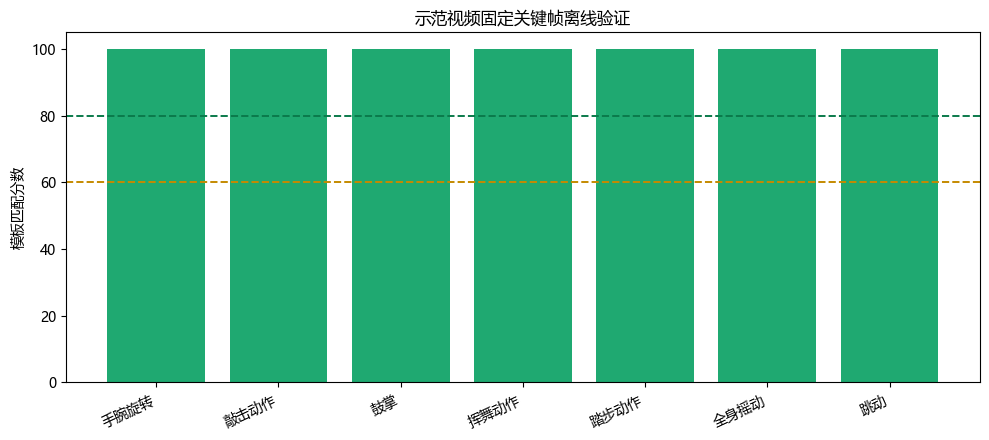

,序号,标签,时间,score,grade,备注
0,1,手腕旋转,00:40,100.0,pass,直接比对
1,2,敲击动作,00:56,100.0,pass,直接比对
2,3,鼓掌,01:07,100.0,pass,直接比对
3,4,挥舞动作,01:30,100.0,pass,直接比对
4,5,踏步动作,01:34,100.0,pass,直接比对
5,6,全身摇动,01:53,100.0,pass,直接比对
6,7,手腕旋转,02:06,100.0,pass,直接比对
7,8,跳动,02:21,100.0,pass,直接比对


In [26]:
offline_result_df = evaluate_demo_keyframes(bundle)
offline_result_df

In [33]:
# 运行该单元会启动 Notebook 内置的提交版 PyQt 界面。
# 准备页会显示资源状态，点击按钮后将同步播放外部音频 `data/generated/audio.wav`。
notebook_window = launch_notebook_pyqt_ui(level_bundle=bundle, camera_id=0)
notebook_window